# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [6]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


Python executable: /Users/aidanzanefrondozo/ai/projects/tinyml-arduino/bin/python
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [2]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset downloaded and extracted.


## 3. Load the Data

In [7]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32
    # 5. Convert labels to zero-based class indices by subtracting 1
    # 1. Load X_train from train/X_train.txt as float32
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"), dtype=np.float32)
    
    # 2. Load y_train from train/y_train.txt as int32
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt"), dtype=np.int32)
    
    # 3. Load X_test from test/X_test.txt as float32
    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"), dtype=np.float32)
    
    # 4. Load y_test from test/y_test.txt as int32
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt"), dtype=np.int32)
    
    # 5. Convert labels to zero-based class indices by subtracting 1
    y_train = y_train - 1
    y_test  = y_test  - 1
    
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO:
# Define num_features and num_classes
num_features = X_train.shape[1]
num_classes  = len(class_names)

# Print shapes and dataset info
print(f"X_train shape : {X_train.shape}")   # (7352, 561)
print(f"y_train shape : {y_train.shape}")   # (7352,)
print(f"X_test shape  : {X_test.shape}")    # (2947, 561)
print(f"y_test shape  : {y_test.shape}")    # (2947,)
print(f"Num features  : {num_features}")    # 561
print(f"Num classes   : {num_classes}")     # 6


X_train shape : (7352, 561)
y_train shape : (7352,)
X_test shape  : (2947, 561)
y_test shape  : (2947,)
Num features  : 561
Num classes   : 6


## 4. Quick Inspection

In [8]:
# TODO:
# Create a small summary table showing:
# - class index,
# - class name, and
# - number of training samples in each class.

# <-- Enter your code here <--#
# Count training samples per class
counts = [np.sum(y_train == i) for i in range(num_classes)]

# Build summary DataFrame
summary = pd.DataFrame({
    "Class Index": range(num_classes),
    "Class Name":  class_names,
    "Train Samples": counts
})

print(summary.to_string(index=False))

 Class Index         Class Name  Train Samples
           0            WALKING           1226
           1   WALKING_UPSTAIRS           1073
           2 WALKING_DOWNSTAIRS            986
           3            SITTING           1286
           4           STANDING           1374
           5             LAYING           1407


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [9]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(64,  activation="relu"),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 256)               143872    
                                                                 
 dense_5 (Dense)             (None, 128)               32896     
                                                                 
 dense_6 (Dense)             (None, 64)                8256      
                                                                 
 dense_7 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [10]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#
history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/40
92/92 [==============================] - 1s 3ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 3ms/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1399 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 0s 3ms/step - loss: 0.1152 - accuracy: 0.9568 - val_loss: 0.2632 - val_accuracy: 0.9123
Epoch 4/40
92/92 [==============================] - 0s 3ms/step - loss: 0.0907 - accuracy: 0.9633 - val_loss: 0.1618 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 3ms/step - loss: 0.0905 - accuracy: 0.9646 - val_loss: 0.2719 - val_accuracy: 0.9205
Epoch 6/40
92/92 [==============================] - 0s 3ms/step - loss: 0.0712 - accuracy: 0.9723 - val_loss: 0.2235 - val_accuracy: 0.9307
Epoch 7/40
92/92 [==============================] - 0s 3ms/step - loss: 0.0588 - accuracy: 0.9776 - val_loss: 0.1442 - val_accuracy: 0.9422
Epoch 8/40
92/92 [==

### Training Curves

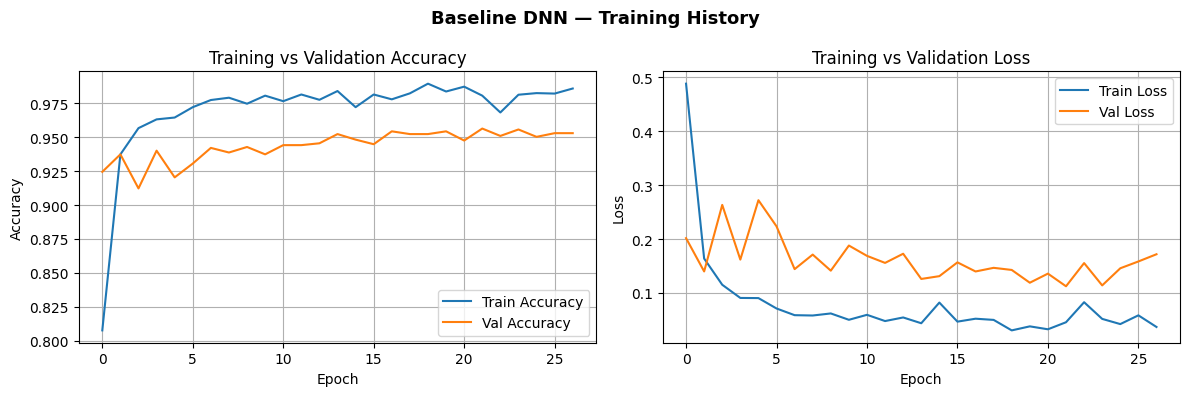

In [ ]:
# <-- Enter your code here <--#
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Accuracy
axes[0].plot(history.history["accuracy"],     label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Training vs Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# 2. Loss
axes[1].plot(history.history["loss"],     label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Training vs Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Baseline DNN — Training History", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Evaluate the Baseline Keras Model

93/93 [==============================] - 0s 707us/step
Test Accuracy: 0.9264

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.86      1.00      0.92       496
  WALKING_UPSTAIRS       0.95      0.85      0.90       471
WALKING_DOWNSTAIRS       0.97      0.91      0.94       420
           SITTING       0.93      0.89      0.91       491
          STANDING       0.87      0.94      0.90       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



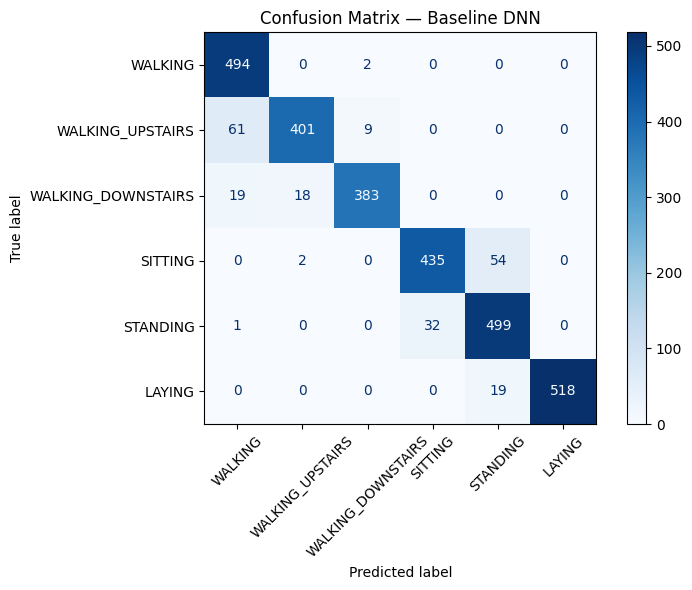

In [ ]:
# <-- Enter your code here <--#
# 1. Predict class probabilities on X_test
y_prob = baseline_model.predict(X_test)

# 2. Convert probabilities to class labels using argmax
y_pred = np.argmax(y_prob, axis=1)

# 3. Compute the test accuracy
test_accuracy = np.mean(y_pred == y_test)
print(f"Test Accuracy: {test_accuracy:.4f}\n")

# 4. Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# 5. Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=45)
ax.set_title("Confusion Matrix — Baseline DNN")
plt.tight_layout()
plt.show()


# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [18]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the TFLite input tensor expects int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#
        if input_details["dtype"] in (np.int8, np.uint8):
            x = (x / input_scale + input_zero_point).astype(input_details["dtype"])
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # Dequantize the output only when the output tensor is int8 or uint8.

        # <-- Enter your code here <--#
        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale
    
        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    # TODO:
    # Create a TFLiteConverter from the Keras model and return the converted FP32 model bytes.

    # <-- Enter your code here <--#
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()
    return tflite_model

## 8. Convert the Baseline Model to TensorFlow Lite

In [ ]:
# <-- Enter your code here <--#
# Convert, save, evaluate
tflite_fp32  = convert_to_tflite_fp32(baseline_model)
fp32_size_kb = save_binary_model(tflite_fp32, "baseline_fp32.tflite")
fp32_acc, fp32_preds = evaluate_tflite_model(tflite_fp32, X_test, y_test)

print(f"FP32 TFLite Model Size : {fp32_size_kb:.2f} KB")
print(f"FP32 TFLite Accuracy   : {fp32_acc:.4f}")

INFO:tensorflow:Assets written to: /var/folders/zf/m3_1trv10w192w5h1_st7k4c0000gn/T/tmpls87bdvy/assets


INFO:tensorflow:Assets written to: /var/folders/zf/m3_1trv10w192w5h1_st7k4c0000gn/T/tmpls87bdvy/assets
2026-04-23 14:59:56.109075: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 14:59:56.109089: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 14:59:56.109204: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/zf/m3_1trv10w192w5h1_st7k4c0000gn/T/tmpls87bdvy
2026-04-23 14:59:56.109871: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 14:59:56.109876: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/zf/m3_1trv10w192w5h1_st7k4c0000gn/T/tmpls87bdvy
2026-04-23 14:59:56.111940: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 14:59:56.145857: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

FP32 TFLite Model Size : 726.75 KB
FP32 TFLite Accuracy   : 0.9264


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [20]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size     = 64

# TODO 1: Compute steps_per_epoch and define pruning_params
steps_per_epoch = int(len(X_train) * 0.8) // batch_size

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs
    )
}

# TODO 2: Wrap a fresh baseline DNN with prune_low_magnitude and compile
pruned_model = prune_low_magnitude(
    build_baseline_model(num_features, num_classes),
    **pruning_params
)

pruned_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

pruned_model.summary()

# Pruning callbacks
pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO 3: Train the pruned model
pruning_history = pruned_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks
)


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 prune_low_magnitude_dense_  (None, 256)               287490    
 8 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 128)               65666     
 9 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 64)                16450     
 10 (PruneLowMagnitude)                                          
                                                                 
 prune_low_magnitude_dense_  (None, 6)                 776       
 11 (PruneLowMagnitude)                                          
                                                                 
Total params: 370382 (1.41 MB)
Trainable params: 18541

## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [21]:
# 1. Convert pruned model (wrappers still attached) to FP32 TFLite
converter_pruned = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
tflite_pruned = converter_pruned.convert()

# 2. Save and evaluate the wrapped pruned model
pruned_size_kb = save_binary_model(tflite_pruned, "pruned_with_wrappers.tflite")
pruned_acc, pruned_preds = evaluate_tflite_model(tflite_pruned, X_test, y_test)

print(f"Pruned (with wrappers) Size     : {pruned_size_kb:.2f} KB")
print(f"Pruned (with wrappers) Accuracy : {pruned_acc:.4f}\n")

# 3. Strip pruning wrappers
model_stripped = strip_pruning(pruned_model)

# 4. Convert stripped model with EXPERIMENTAL_SPARSITY optimization
converter_sparse = tf.lite.TFLiteConverter.from_keras_model(model_stripped)
converter_sparse.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
tflite_sparse = converter_sparse.convert()

# 5. Save and evaluate the stripped sparse model
sparse_size_kb = save_binary_model(tflite_sparse, "pruned_stripped_sparse.tflite")
sparse_acc, sparse_preds = evaluate_tflite_model(tflite_sparse, X_test, y_test)

print(f"Pruned + Stripped Sparse Size     : {sparse_size_kb:.2f} KB")
print(f"Pruned + Stripped Sparse Accuracy : {sparse_acc:.4f}\n")

# Summary comparison
print("=" * 50)
print(f"{'Model':<30} {'Size (KB)':>10} {'Accuracy':>10}")
print("=" * 50)
print(f"{'FP32 Baseline':<30} {fp32_size_kb:>10.2f} {fp32_acc:>10.4f}")
print(f"{'Pruned (wrappers)':<30} {pruned_size_kb:>10.2f} {pruned_acc:>10.4f}")
print(f"{'Pruned + Stripped Sparse':<30} {sparse_size_kb:>10.2f} {sparse_acc:>10.4f}")
print("=" * 50)

INFO:tensorflow:Assets written to: /var/folders/zf/m3_1trv10w192w5h1_st7k4c0000gn/T/tmpy8s5nx24/assets


INFO:tensorflow:Assets written to: /var/folders/zf/m3_1trv10w192w5h1_st7k4c0000gn/T/tmpy8s5nx24/assets
2026-04-23 15:23:05.409501: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 15:23:05.409516: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 15:23:05.409644: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/zf/m3_1trv10w192w5h1_st7k4c0000gn/T/tmpy8s5nx24
2026-04-23 15:23:05.411803: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 15:23:05.411817: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/zf/m3_1trv10w192w5h1_st7k4c0000gn/T/tmpy8s5nx24
2026-04-23 15:23:05.420049: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 15:23:05.468694: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

Pruned (with wrappers) Size     : 1454.21 KB
Pruned (with wrappers) Accuracy : 0.9060

INFO:tensorflow:Assets written to: /var/folders/zf/m3_1trv10w192w5h1_st7k4c0000gn/T/tmpuzwx0d5j/assets


INFO:tensorflow:Assets written to: /var/folders/zf/m3_1trv10w192w5h1_st7k4c0000gn/T/tmpuzwx0d5j/assets


Pruned + Stripped Sparse Size     : 194.38 KB
Pruned + Stripped Sparse Accuracy : 0.9060

Model                           Size (KB)   Accuracy
FP32 Baseline                      726.75     0.9264
Pruned (wrappers)                 1454.21     0.9060
Pruned + Stripped Sparse           194.38     0.9060


2026-04-23 15:23:06.128187: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 15:23:06.128202: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 15:23:06.128315: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/zf/m3_1trv10w192w5h1_st7k4c0000gn/T/tmpuzwx0d5j
2026-04-23 15:23:06.128808: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 15:23:06.128817: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/zf/m3_1trv10w192w5h1_st7k4c0000gn/T/tmpuzwx0d5j
2026-04-23 15:23:06.130410: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 15:23:06.143789: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/zf/m3_1trv10w192w5h1_st7k4c0000gn/T/tmpuzwx0d5j
2026-04-

## 11. Part I Comparison: Accuracy and Model Size

In [22]:
comparison_df = pd.DataFrame([
    {
        "Model":           "Baseline",
        "Format":          "FP32 TFLite",
        "Test Accuracy":   fp32_acc,
        "Model Size (KB)": fp32_size_kb
    },
    {
        "Model":           "Pruned (with wrappers)",
        "Format":          "FP32 TFLite",
        "Test Accuracy":   pruned_acc,
        "Model Size (KB)": pruned_size_kb
    },
    {
        "Model":           "Pruned + Stripped Sparse",
        "Format":          "FP32 TFLite",
        "Test Accuracy":   sparse_acc,
        "Model Size (KB)": sparse_size_kb
    }
])

# Round for readability
comparison_df["Test Accuracy"]   = comparison_df["Test Accuracy"].round(4)
comparison_df["Model Size (KB)"] = comparison_df["Model Size (KB)"].round(2)

print(comparison_df.to_string(index=False))

                   Model      Format  Test Accuracy  Model Size (KB)
                Baseline FP32 TFLite         0.9264           726.75
  Pruned (with wrappers) FP32 TFLite         0.9060          1454.21
Pruned + Stripped Sparse FP32 TFLite         0.9060           194.38


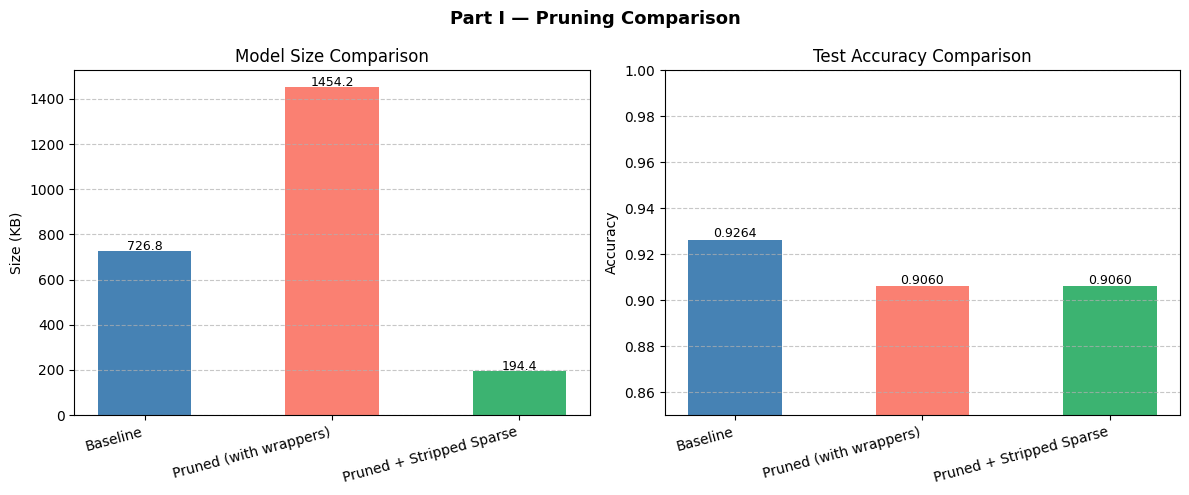

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = comparison_df["Model"]
x      = range(len(models))

# 1. Model Size bar chart
axes[0].bar(x, comparison_df["Model Size (KB)"], color=["steelblue", "salmon", "mediumseagreen"], width=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15, ha="right")
axes[0].set_title("Model Size Comparison")
axes[0].set_ylabel("Size (KB)")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)
for i, v in enumerate(comparison_df["Model Size (KB)"]):
    axes[0].text(i, v + 5, f"{v:.1f}", ha="center", fontsize=9)

# 2. Test Accuracy bar chart
axes[1].bar(x, comparison_df["Test Accuracy"], color=["steelblue", "salmon", "mediumseagreen"], width=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=15, ha="right")
axes[1].set_title("Test Accuracy Comparison")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.85, 1.00)   # zoom in to make differences visible
axes[1].grid(axis="y", linestyle="--", alpha=0.7)
for i, v in enumerate(comparison_df["Test Accuracy"]):
    axes[1].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=9)

plt.suptitle("Part I — Pruning Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Confusion Matrix for the Stripped Sparse Model

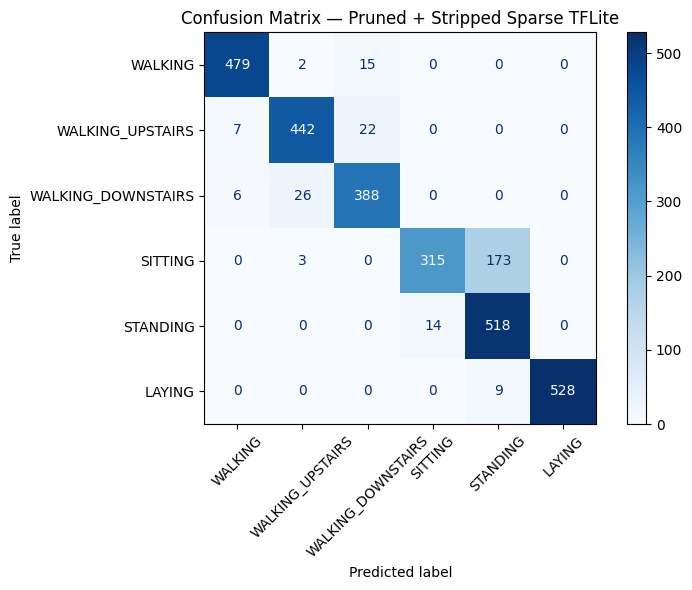

Classification Report — Pruned + Stripped Sparse TFLite
                    precision    recall  f1-score   support

           WALKING       0.97      0.97      0.97       496
  WALKING_UPSTAIRS       0.93      0.94      0.94       471
WALKING_DOWNSTAIRS       0.91      0.92      0.92       420
           SITTING       0.96      0.64      0.77       491
          STANDING       0.74      0.97      0.84       532
            LAYING       1.00      0.98      0.99       537

          accuracy                           0.91      2947
         macro avg       0.92      0.90      0.90      2947
      weighted avg       0.92      0.91      0.90      2947



In [ ]:
# Confusion matrix
cm   = confusion_matrix(y_test, sparse_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=45)
ax.set_title("Confusion Matrix — Pruned + Stripped Sparse TFLite")
plt.tight_layout()
plt.show()

# Classification report
print("Classification Report — Pruned + Stripped Sparse TFLite")
print(classification_report(y_test, sparse_preds, target_names=class_names))


# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [ ]:
# <-- Enter your code here <--#
# 1. Convert pruned model (with mask) to float16
converter_pruned_fp16 = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
converter_pruned_fp16.optimizations    = [tf.lite.Optimize.DEFAULT]
converter_pruned_fp16.target_spec.supported_types = [tf.float16]
tflite_pruned_fp16 = converter_pruned_fp16.convert()

# 2. Save and evaluate pruned + float16 (with mask)
pruned_fp16_size_kb = save_binary_model(tflite_pruned_fp16, "pruned_with_mask_fp16.tflite")
pruned_fp16_acc, pruned_fp16_preds = evaluate_tflite_model(tflite_pruned_fp16, X_test, y_test)

print(f"Pruned FP16 (with mask) Size     : {pruned_fp16_size_kb:.2f} KB")
print(f"Pruned FP16 (with mask) Accuracy : {pruned_fp16_acc:.4f}\n")

# 3. Convert stripped sparse model to float16 + sparsity
converter_sparse_fp16 = tf.lite.TFLiteConverter.from_keras_model(model_stripped)
converter_sparse_fp16.optimizations    = [tf.lite.Optimize.DEFAULT,
                                          tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter_sparse_fp16.target_spec.supported_types = [tf.float16]
tflite_sparse_fp16 = converter_sparse_fp16.convert()

# 4. Save and evaluate stripped sparse + float16
sparse_fp16_size_kb = save_binary_model(tflite_sparse_fp16, "pruned_stripped_sparse_fp16.tflite")
sparse_fp16_acc, sparse_fp16_preds = evaluate_tflite_model(tflite_sparse_fp16, X_test, y_test)

print(f"Pruned + Stripped Sparse FP16 Size     : {sparse_fp16_size_kb:.2f} KB")
print(f"Pruned + Stripped Sparse FP16 Accuracy : {sparse_fp16_acc:.4f}\n")

# Summary
print("=" * 55)
print(f"{'Model':<35} {'Size (KB)':>10} {'Accuracy':>10}")
print("=" * 55)
print(f"{'FP32 Baseline':<35} {fp32_size_kb:>10.2f} {fp32_acc:>10.4f}")
print(f"{'Pruned FP16 (with mask)':<35} {pruned_fp16_size_kb:>10.2f} {pruned_fp16_acc:>10.4f}")
print(f"{'Pruned + Stripped Sparse FP16':<35} {sparse_fp16_size_kb:>10.2f} {sparse_fp16_acc:>10.4f}")
print("=" * 55)

INFO:tensorflow:Assets written to: /var/folders/zf/m3_1trv10w192w5h1_st7k4c0000gn/T/tmpwq3_mn1n/assets


INFO:tensorflow:Assets written to: /var/folders/zf/m3_1trv10w192w5h1_st7k4c0000gn/T/tmpwq3_mn1n/assets
2026-04-23 15:26:45.557626: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 15:26:45.557652: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 15:26:45.558467: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/zf/m3_1trv10w192w5h1_st7k4c0000gn/T/tmpwq3_mn1n
2026-04-23 15:26:45.560667: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 15:26:45.560677: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/zf/m3_1trv10w192w5h1_st7k4c0000gn/T/tmpwq3_mn1n
2026-04-23 15:26:45.570637: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 15:26:45.622107: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

Pruned FP16 (with mask) Size     : 732.62 KB
Pruned FP16 (with mask) Accuracy : 0.9057

INFO:tensorflow:Assets written to: /var/folders/zf/m3_1trv10w192w5h1_st7k4c0000gn/T/tmpy8gaqrrt/assets


INFO:tensorflow:Assets written to: /var/folders/zf/m3_1trv10w192w5h1_st7k4c0000gn/T/tmpy8gaqrrt/assets
2026-04-23 15:26:46.585904: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 15:26:46.585920: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 15:26:46.586039: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/zf/m3_1trv10w192w5h1_st7k4c0000gn/T/tmpy8gaqrrt
2026-04-23 15:26:46.586508: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 15:26:46.586513: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/zf/m3_1trv10w192w5h1_st7k4c0000gn/T/tmpy8gaqrrt
2026-04-23 15:26:46.587593: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 15:26:46.602754: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

Pruned + Stripped Sparse FP16 Size     : 129.27 KB
Pruned + Stripped Sparse FP16 Accuracy : 0.9057

Model                                Size (KB)   Accuracy
FP32 Baseline                           726.75     0.9264
Pruned FP16 (with mask)                 732.62     0.9057
Pruned + Stripped Sparse FP16           129.27     0.9057


## 12. Part II Comparison: Accuracy and Model Size

In [ ]:
# TODO:
# Create a Part II comparison DataFrame with the columns:
# Model, Format, Test Accuracy, Model Size (KB)
#
# Include:
# - pruned FP32 with mask
# - stripped sparse FP32
# - pruned float16 with mask
# - stripped sparse float16
comparison_df_p2 = pd.DataFrame([
    {
        "Model":           "Pruned (with mask)",
        "Format":          "FP32 TFLite",
        "Test Accuracy":   pruned_acc,
        "Model Size (KB)": pruned_size_kb
    },
    {
        "Model":           "Pruned + Stripped Sparse",
        "Format":          "FP32 TFLite",
        "Test Accuracy":   sparse_acc,
        "Model Size (KB)": sparse_size_kb
    },
    {
        "Model":           "Pruned (with mask)",
        "Format":          "Float16 TFLite",
        "Test Accuracy":   pruned_fp16_acc,
        "Model Size (KB)": pruned_fp16_size_kb
    },
    {
        "Model":           "Pruned + Stripped Sparse",
        "Format":          "Float16 TFLite",
        "Test Accuracy":   sparse_fp16_acc,
        "Model Size (KB)": sparse_fp16_size_kb
    }
])


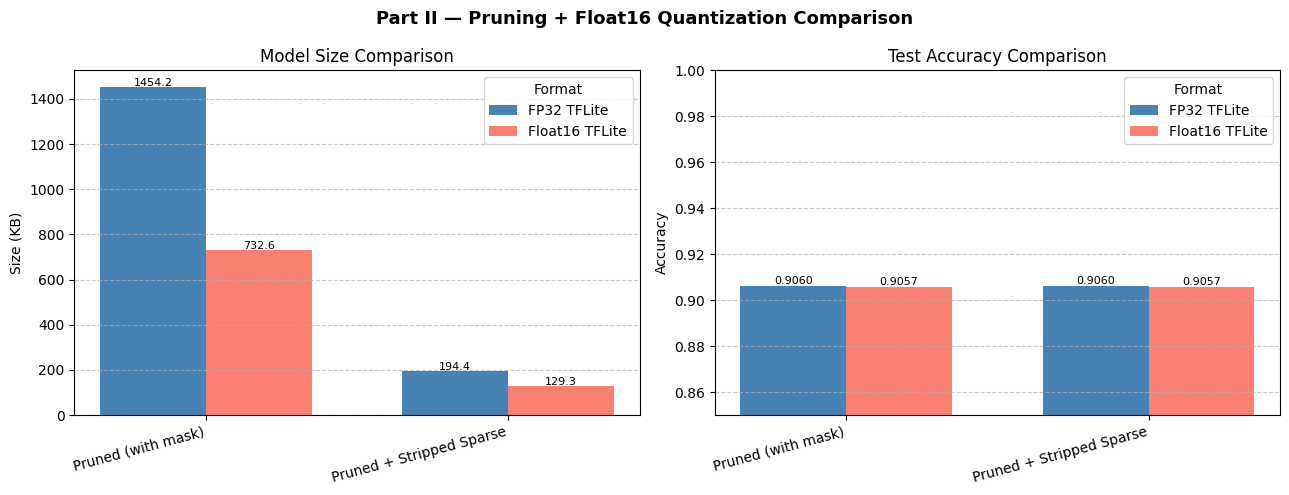

In [ ]:
# TODO:
# Plot:
# 1. a bar chart of Part II model sizes
# 2. a bar chart of Part II test accuracies

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Group by format for grouped bar chart
formats = comparison_df_p2["Format"].unique()       # FP32, Float16
models  = comparison_df_p2["Model"].unique()         # Pruned w/ mask, Stripped Sparse
x       = np.arange(len(models))
width   = 0.35
colors  = ["steelblue", "salmon"]

for i, (fmt, color) in enumerate(zip(formats, colors)):
    subset = comparison_df_p2[comparison_df_p2["Format"] == fmt]

    # 1. Size bars
    bars_size = axes[0].bar(x + i * width, subset["Model Size (KB)"],
                            width=width, label=fmt, color=color)
    for bar in bars_size:
        axes[0].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 5,
                     f"{bar.get_height():.1f}",
                     ha="center", fontsize=8)

    # 2. Accuracy bars
    bars_acc = axes[1].bar(x + i * width, subset["Test Accuracy"],
                           width=width, label=fmt, color=color)
    for bar in bars_acc:
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.001,
                     f"{bar.get_height():.4f}",
                     ha="center", fontsize=8)

# Size chart formatting
axes[0].set_xticks(x + width / 2)
axes[0].set_xticklabels(models, rotation=15, ha="right")
axes[0].set_title("Model Size Comparison")
axes[0].set_ylabel("Size (KB)")
axes[0].legend(title="Format")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# Accuracy chart formatting
axes[1].set_xticks(x + width / 2)
axes[1].set_xticklabels(models, rotation=15, ha="right")
axes[1].set_title("Test Accuracy Comparison")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.85, 1.00)
axes[1].legend(title="Format")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.suptitle("Part II — Pruning + Float16 Quantization Comparison",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Confusion Matrix for the Stripped Sparse + Float16 Model

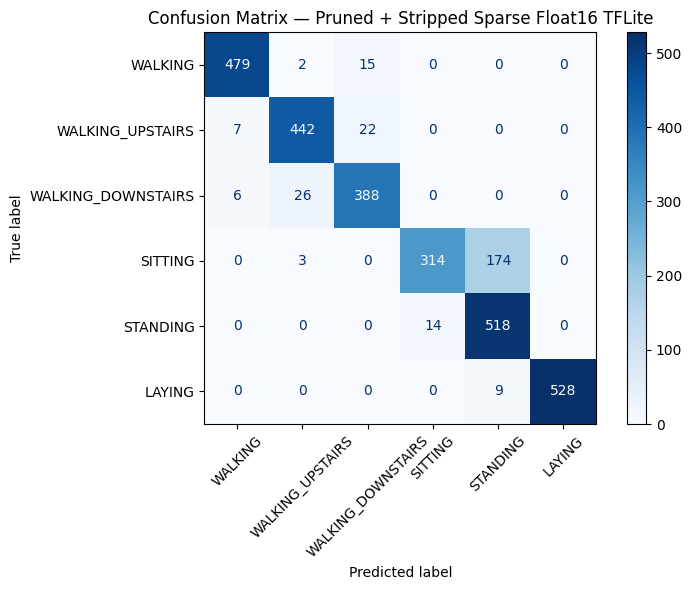

Classification Report — Pruned + Stripped Sparse Float16 TFLite
                    precision    recall  f1-score   support

           WALKING       0.97      0.97      0.97       496
  WALKING_UPSTAIRS       0.93      0.94      0.94       471
WALKING_DOWNSTAIRS       0.91      0.92      0.92       420
           SITTING       0.96      0.64      0.77       491
          STANDING       0.74      0.97      0.84       532
            LAYING       1.00      0.98      0.99       537

          accuracy                           0.91      2947
         macro avg       0.92      0.90      0.90      2947
      weighted avg       0.92      0.91      0.90      2947



In [28]:
# TODO:
# Plot the confusion matrix for the stripped sparse + float16 TFLite model.
# Print the classification report for the stripped sparse + float16 TFLite model.

# <-- Enter your code here <--#
# Confusion matrix
cm   = confusion_matrix(y_test, sparse_fp16_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=45)
ax.set_title("Confusion Matrix — Pruned + Stripped Sparse Float16 TFLite")
plt.tight_layout()
plt.show()

# Classification report
print("Classification Report — Pruned + Stripped Sparse Float16 TFLite")
print(classification_report(y_test, sparse_fp16_preds, target_names=class_names))

## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached?  
#### No, with pruning the size actually increased.     
2. Why does `strip_pruning(...)` matter before export?  
#### It removes all training-time scaffolding.  
3. Which model had the smallest file size in this notebook?  
#### The pruned+stripped sparse float 16.  
4. Did float16 quantization noticeably change the test accuracy?  
#### No, it did not.  
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?  
#### I would choose the pruned+stripped sparse float 16 version because it is the smallest and has the same accuracy as the baseline.


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
